# 13. Capacity Expansion II — Multi-Technology Portfolio

Model 12 let a single technology's capacity respond to economics, with everything else fixed. This
model extends that same idea to **three competing technologies simultaneously** — solar, wind, and
a battery — all left as free variables at once, forced to share the same limited capital.

The objective is to model a system where `Solar_PV`, `Wind`, and `Battery` are all
`p_nom_extendable=True`, alongside a fixed industrial load and a two-directional grid connection. The
solver now has to answer a genuinely coupled question: not just "how much solar" or "how much wind"
in isolation, but the **best combination** of the three, given that solar and wind have different
(and only partially overlapping) weather-driven output profiles, and that battery capacity is only
worth building if there's enough price or generation volatility to arbitrage.

## Why this is a different problem from three separate single-technology decisions
Solar and wind rarely peak at the same time, so a portfolio of both smooths total renewable output
more than either alone — this is a **complementarity effect**, and it can only be captured by
optimizing them jointly, since each technology's optimal size now depends on how much of the other
is already installed. The battery adds a second effect: its economic value depends on the *volatility*
of the system it's shifting energy within, which itself depends on how much solar and wind capacity
the solver has already chosen to build. Solving all three at once is what lets the model discover
these interactions; solving them one at a time, sequentially, would not.

## System Topology
1. **Bus:** a single electrical bus.
2. **Generators (Source):** `Solar_PV` and `Wind`, both `p_nom_extendable=True`, each with its own
   annualized `capital_cost`, `p_nom_max` site limit, and weather-driven capacity factor.
3. **Generators (Grid, two-directional):** `Grid_Import` and `Grid_Export`, unchanged, fixed
   capacity.
4. **Loads:** the same day/night industrial load used since Model 03.
5. **Storage:** `Battery`, now `p_nom_extendable=True` as well, with its own annualized capital cost
   (which, following Model 06's logic, scales with both power and energy capacity since a
   `StorageUnit` needs power electronics as well as an energy-storage medium).


In [1]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.append('../')
from utils.viz_utils import set_nature_style
set_nature_style()

df_pv = pd.read_csv('../data/processed/pv_2025_hourly.csv', index_col='time', parse_dates=True)
df_wind = pd.read_csv('../data/processed/wind_2025_hourly.csv', index_col='time', parse_dates=True)
df_price = pd.read_csv('../data/processed/electricity_price_2025_hourly.csv', index_col='time', parse_dates=True)

perfect_index = pd.date_range(start='2025-01-01 00:00', end='2025-12-31 23:00', freq='1h')
df_pv.index = perfect_index
df_wind.index = perfect_index
df_price.index = perfect_index

df_pv['capacity_factor'] = df_pv['pv_generation_kw'].clip(upper=1.0)
df_wind['capacity_factor'] = df_wind['wind_generation_kw'].clip(upper=1.0)


## Technical Parameters

Solar's parameters carry over from Model 12. Wind and the battery gain the same
`p_nom_extendable`/`capital_cost`/`p_nom_max` treatment. The battery's capital cost is expressed per
MW of power rating, but embeds its fixed 2-hour duration, so building 1 MW of battery power
automatically means building 2 MWh of battery energy alongside it (a simplification — in a full
model, power and energy capacity could be split into two independent decision variables).


In [2]:
DISCOUNT_RATE = 0.04

def annuity(lifetime_years, investment, fom_percent):
    r = DISCOUNT_RATE
    crf = (r * (1 + r) ** lifetime_years) / ((1 + r) ** lifetime_years - 1)
    return investment * (crf + fom_percent / 100.0)

tech_param = {
    'solar_pv': {
        'p_nom_max': 30.0,
        'capital_cost': annuity(30, 550_000, 2.0),
        'marginal_cost': 0.0
    },
    'wind': {
        'p_nom_max': 30.0,
        'capital_cost': annuity(25, 1_100_000, 2.5),
        'marginal_cost': 0.0
    },
    'battery': {
        'p_nom_max': 10.0,             # Max power rating, MW (implies up to 20 MWh at 2h duration)
        'max_hours': 2.0,
        'capital_cost': annuity(15, 280_000 * 2, 1.5),   # EUR/MW/year, 2h duration baked in
        'efficiency_store': 0.95,
        'efficiency_dispatch': 0.95
    },
    'market_grid': {
        'import_p_nom': 20.0,
        'export_p_nom': 18.0
    },
    'demand': {
        'day_load_mw': 8.0,
        'night_load_mw': 4.0
    }
}

print(f"Solar capital cost:   EUR {tech_param['solar_pv']['capital_cost']:,.0f} / MW / year")
print(f"Wind capital cost:    EUR {tech_param['wind']['capital_cost']:,.0f} / MW / year")
print(f"Battery capital cost: EUR {tech_param['battery']['capital_cost']:,.0f} / MW / year (2h duration)")


Solar capital cost:   EUR 42,807 / MW / year
Wind capital cost:    EUR 97,913 / MW / year
Battery capital cost: EUR 58,767 / MW / year (2h duration)


## Initializing the Network

A single electrical bus, as in earlier models.


In [3]:
n = pypsa.Network()
n.set_snapshots(df_pv.index)
n.add("Bus", "electricity_bus")


Index(['electricity_bus'], dtype='object')

## Adding Generators and the Grid Connection

`Solar_PV` and `Wind` are both extendable now, each with its own site limit and capital cost.
`Grid_Import` and `Grid_Export` remain fixed-capacity, exactly as in every earlier model.


In [4]:
n.add("Generator", "Solar_PV", bus="electricity_bus",
      p_nom_extendable=True,
      p_nom_max=tech_param['solar_pv']['p_nom_max'],
      p_max_pu=df_pv['capacity_factor'],
      capital_cost=tech_param['solar_pv']['capital_cost'],
      marginal_cost=tech_param['solar_pv']['marginal_cost'])

n.add("Generator", "Wind", bus="electricity_bus",
      p_nom_extendable=True,
      p_nom_max=tech_param['wind']['p_nom_max'],
      p_max_pu=df_wind['capacity_factor'],
      capital_cost=tech_param['wind']['capital_cost'],
      marginal_cost=tech_param['wind']['marginal_cost'])

n.add("Generator", "Grid_Import", bus="electricity_bus",
      p_nom=tech_param['market_grid']['import_p_nom'],
      marginal_cost=df_price['price'])

n.add("Generator", "Grid_Export", bus="electricity_bus",
      p_nom=tech_param['market_grid']['export_p_nom'],
      p_min_pu=-1.0, p_max_pu=0.0,
      marginal_cost=df_price['price'])


Index(['Grid_Export'], dtype='object')

## Adding the Electrical Demand

The same day/night industrial load used since Model 03.


In [5]:
is_daytime = (n.snapshots.hour >= 8) & (n.snapshots.hour < 18)
load_profile = np.where(is_daytime, tech_param['demand']['day_load_mw'], tech_param['demand']['night_load_mw'])
load_profile = pd.Series(load_profile, index=n.snapshots)

n.add("Load", "Industrial_Load", bus="electricity_bus", p_set=load_profile)


Index(['Industrial_Load'], dtype='object')

## Adding the Battery

`p_nom_extendable=True` and `p_nom_max` work identically for a `StorageUnit` as for a `Generator` -
the solver chooses the power rating, and `max_hours` fixes the resulting energy capacity as a
multiple of whatever power rating gets chosen.


In [6]:
n.add("StorageUnit", "Battery", bus="electricity_bus",
      p_nom_extendable=True,
      p_nom_max=tech_param['battery']['p_nom_max'],
      max_hours=tech_param['battery']['max_hours'],
      capital_cost=tech_param['battery']['capital_cost'],
      efficiency_store=tech_param['battery']['efficiency_store'],
      efficiency_dispatch=tech_param['battery']['efficiency_dispatch'],
      cyclic_state_of_charge=True)


Index(['Battery'], dtype='object')

## Running the Optimization

Three extendable components, one shared bus, and a full year of hourly dispatch - the solver jointly
sizes all three technologies and schedules their operation in a single combined investment-and-
dispatch problem.


In [7]:
status, condition = n.optimize(solver_name='highs')

print(f"Solver Status: {status}")
print(f"Total Objective Value (Annualized Capital + Net Operating Cost): EUR {n.objective:,.2f}")


Index(['electricity_bus'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 33.78it/s]
INFO:linopy.io: Writing time: 1.23s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 61323 primals, 140166 duals
Objective: -2.40e+06
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


Solver Status: ok
Total Objective Value (Annualized Capital + Net Operating Cost): EUR -2,395,827.07


## Analyzing the Results

We report the optimal capacity chosen for all three technologies together, and check how close each
came to its own site limit - a technology sitting exactly at its `p_nom_max` suggests the model would
build even more if the constraint were relaxed, while one sitting below its limit suggests the solver
found a genuine cost-optimal interior point.


Optimal Solar PV Capacity:   26.77 MW  (limit: 30.0 MW)
Optimal Wind Capacity:       30.00 MW  (limit: 30.0 MW)
Optimal Battery Capacity:    10.00 MW / 20.00 MWh  (limit: 10.0 MW)
---------------------------------------------
Solar CAPEX:    EUR 1,145,825.87 / year (24.5%)
Wind CAPEX:     EUR 2,937,394.77 / year (62.9%)
Battery CAPEX:  EUR   587,670.16 / year (12.6%)
Total CAPEX:    EUR 4,670,890.80 / year


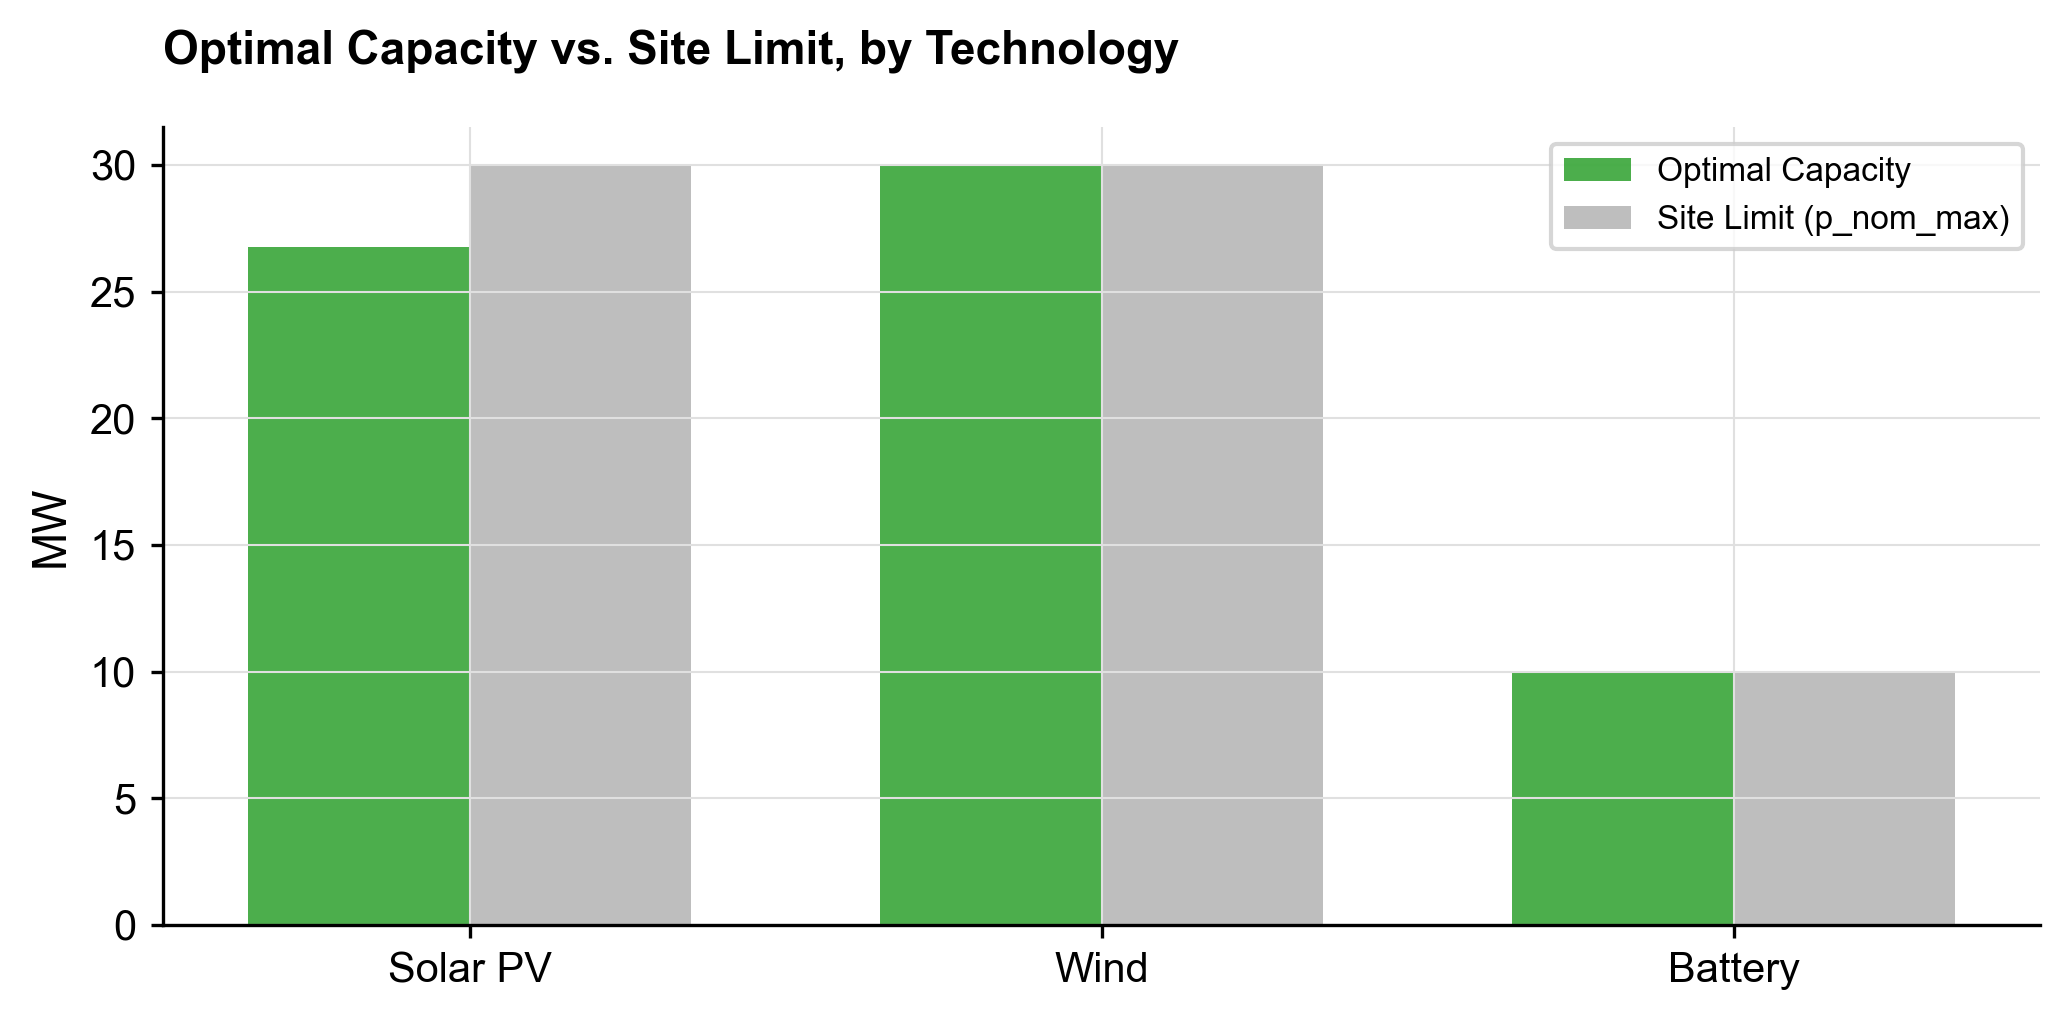

In [8]:
optimal_solar_mw = n.generators.at['Solar_PV', 'p_nom_opt']
optimal_wind_mw = n.generators.at['Wind', 'p_nom_opt']
optimal_battery_mw = n.storage_units.at['Battery', 'p_nom_opt']
optimal_battery_mwh = optimal_battery_mw * tech_param['battery']['max_hours']

print(f"Optimal Solar PV Capacity:  {optimal_solar_mw:>6.2f} MW  (limit: {tech_param['solar_pv']['p_nom_max']:.1f} MW)")
print(f"Optimal Wind Capacity:      {optimal_wind_mw:>6.2f} MW  (limit: {tech_param['wind']['p_nom_max']:.1f} MW)")
print(f"Optimal Battery Capacity:   {optimal_battery_mw:>6.2f} MW / {optimal_battery_mwh:.2f} MWh  (limit: {tech_param['battery']['p_nom_max']:.1f} MW)")

solar_capex = optimal_solar_mw * tech_param['solar_pv']['capital_cost']
wind_capex = optimal_wind_mw * tech_param['wind']['capital_cost']
battery_capex = optimal_battery_mw * tech_param['battery']['capital_cost']
total_capex = solar_capex + wind_capex + battery_capex

print("-" * 45)
print(f"Solar CAPEX:    EUR {solar_capex:>12,.2f} / year ({100*solar_capex/total_capex:.1f}%)")
print(f"Wind CAPEX:     EUR {wind_capex:>12,.2f} / year ({100*wind_capex/total_capex:.1f}%)")
print(f"Battery CAPEX:  EUR {battery_capex:>12,.2f} / year ({100*battery_capex/total_capex:.1f}%)")
print(f"Total CAPEX:    EUR {total_capex:>12,.2f} / year")

# Bar chart comparing chosen capacity against each technology's site limit
fig, ax = plt.subplots()
techs = ['Solar PV', 'Wind', 'Battery']
optimal_vals = [optimal_solar_mw, optimal_wind_mw, optimal_battery_mw]
limit_vals = [tech_param['solar_pv']['p_nom_max'], tech_param['wind']['p_nom_max'], tech_param['battery']['p_nom_max']]

x = np.arange(len(techs))
width = 0.35
ax.bar(x - width/2, optimal_vals, width, label='Optimal Capacity', color='#2ca02c', alpha=0.85)
ax.bar(x + width/2, limit_vals, width, label='Site Limit (p_nom_max)', color='#7f7f7f', alpha=0.5)
ax.set_ylabel('MW')
ax.set_xticks(x)
ax.set_xticklabels(techs)
ax.set_title('Optimal Capacity vs. Site Limit, by Technology', pad=15, loc='left', fontweight='bold')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()
